STRUCTURE OF THIS DOCUMENT
1. Imports
2. Collection of Data & Preprocessing
3. EDA
4. Preparation of Data for Training + Benchmark Model - Simple decision tree
5. 2 Deep Learning Models Architectures (CNNs)
6. Deep Learning Model Fitting
7. Evaluation of the 2 Models
8. Hyperparameter Tuning

In [1]:
# Packages

import os
import glob

import random
import numpy as np
import pandas as pd
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

from PIL import Image
import cv2
from skimage import exposure
from tabulate import tabulate

import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse, confusion_matrix, f1_score, accuracy_score
from sklearn.discriminant_analysis import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from sklearn.discriminant_analysis import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score, precision_score, recall_score

import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, AveragePooling2D, Embedding, Flatten, Dense, Dropout, Input, LeakyReLU
from keras.metrics import Precision, Recall, BinaryAccuracy

from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.optimizers.legacy import Adam, SGD, RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from matplotlib import pyplot as plt

import keras_tuner


Using TensorFlow backend


In [2]:
# Import data, EDA, preprocessing

NOTUMOR = 0
PITUITARY = 1
MENINGIOMA = 2
GLIOMA = 3

data = []

def pre_process(file_paths, brain_tumor_type, is_gaussian_blur=False):
    response = []
    count = 0
    for path in file_paths:
        # option L greyscales the image
        img = Image.open(path)

        # EDA - number of channels + size of image
        # print(img.getbands(), img.size)

        img = img.convert('L')

        # EDA - pixel intensity distribution of an image
        # pixel_values = np.array(img).flatten()
        # plt.hist(pixel_values, bins=256, range=(0, 1), density=True)
        # plt.xlabel('Pixel Intensity')
        # plt.ylabel('Density')
        # plt.title('Pixel Intensity Distribution')
        # plt.show()

        img_arr = np.array(img.resize((128, 128), Image.Resampling.NEAREST))

        # Noise reduction
        if is_gaussian_blur:
            img_arr = cv2.GaussianBlur(img_arr, (5, 5), 0)

        # median blur preserves edges better
        img_arr = cv2.medianBlur(img_arr, 5)

        # Normalise to values between 0 and 1 inclusive rather than integers 0 to 255 inclusive
        img_arr = img_arr / 255.0

        # Contrast enhancement
        img_arr = exposure.equalize_hist(img_arr)

        response = brain_tumor_type
        data.append((img_arr, response))

        count += 1
    return count

# Get file paths
fp_notumor_1 = glob.glob('Data_Images/testing/notumor/*')
fp_notumor_2 = glob.glob('Data_Images/training/notumor/*')
num_no_tumor = pre_process(fp_notumor_1, NOTUMOR) + pre_process(fp_notumor_2, NOTUMOR)

fp_pituitary_1 = glob.glob('Data_Images/testing/pituitary/*')
fp_pituitary_2 = glob.glob('Data_Images/training/pituitary/*')
num_pituitary = pre_process(fp_pituitary_1, PITUITARY) + pre_process(fp_pituitary_2, PITUITARY)

fp_meningioma_1 = glob.glob('Data_Images/testing/meningioma/*')
fp_meningioma_2 = glob.glob('Data_Images/training/meningioma/*')
num_meningioma = pre_process(fp_meningioma_1, MENINGIOMA) + pre_process(fp_meningioma_2, MENINGIOMA)

fp_glioma1 = glob.glob('Data_Images/testing/glioma/*')
fp_glioma2 = glob.glob('Data_Images/training/glioma/*')
num_glioma = pre_process(fp_glioma1, GLIOMA) + pre_process(fp_glioma2, GLIOMA)

In [3]:
# EDA - table
total = num_glioma + num_meningioma + num_pituitary + num_no_tumor

table = [
    ["No Tumor", num_no_tumor, num_no_tumor / total * 100],
    ["Pituitary", num_pituitary, num_pituitary / total * 100],
    ["Meningioma", num_meningioma, num_meningioma / total * 100],
    ["Glioma", num_glioma, num_glioma / total * 100],
    ["TOTAL", total, 100]
]

print(tabulate(table, headers=["Classification", "Count", "Percentage"], floatfmt=".2f"))

Classification      Count    Percentage
----------------  -------  ------------
No Tumor             2000         28.48
Pituitary            1757         25.02
Meningioma           1645         23.42
Glioma               1621         23.08
TOTAL                7023        100.00


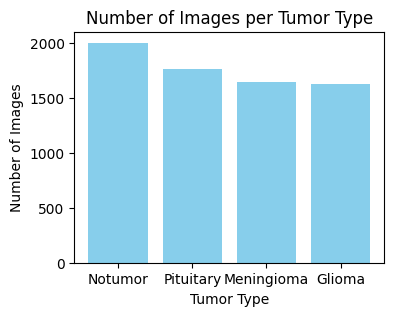

In [4]:
# EDA - histogram
categories = ['Notumor', 'Pituitary', 'Meningioma', 'Glioma']
counts = [num_no_tumor, num_pituitary, num_meningioma, num_glioma]
plt.figure(figsize=(4, 3))
plt.bar(categories, counts, color='skyblue')
plt.xlabel('Tumor Type')
plt.ylabel('Number of Images')
plt.title('Number of Images per Tumor Type')
plt.show()

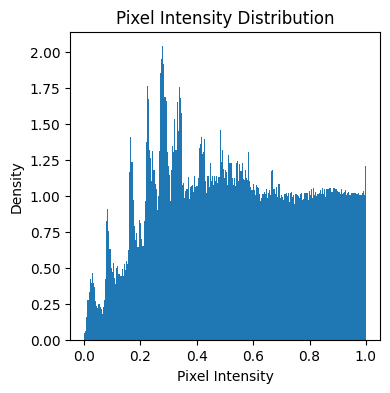

In [5]:
# EDA - pixel intensity distribution of an image
sample = random.sample(data, 7023)

sample_pixel_values = np.array([entry[0] for entry in sample]).flatten()

pixel_values = np.array(sample_pixel_values).flatten()
plt.figure(figsize=(4, 4))
plt.hist(pixel_values, bins=256, range=(0, 1), density=True)
plt.xlabel('Pixel Intensity')
plt.ylabel('Density')
plt.title('Pixel Intensity Distribution')
plt.show()

In [6]:
# Preparation for training

X = np.array([entry[0] for entry in data]) # Images
y = np.array([entry[1] for entry in data]) # Response

X_flat = X.reshape(X.shape[0], -1)

X_main, X_test, y_main, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2024
)
X_train, X_val, y_train, y_val = train_test_split(
    X_main, y_main, test_size=0.25, random_state=2024
)
# print(X_train.shape, X_val.shape, X_test.shape)
# print(y_train.shape, y_val.shape, y_test.shape)

# BENCHMARK MODEL - Decision Tree

X_main_flat = X_main.reshape(X_main.shape[0], -1)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

benchmark_model = DecisionTreeClassifier(random_state=2024)
benchmark_model.fit(X_train_flat, y_train)

y_pred = benchmark_model.predict(X_test_flat)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

test_precision = precision_score(y_test, y_pred, average='weighted')
print(f'Test Precision: {test_precision:.4f}')

test_recall = recall_score(y_test, y_pred, average='weighted')
print(f'Test Recall: {test_recall:.4f}')

test_f1 = f1_score(y_test, y_pred, average='weighted')
print(f'Test F1: {test_f1:.4f}')

print(classification_report(y_test, y_pred))

# Prepare for neural network
X_train = X_train.reshape(-1, 128, 128, 1)
X_val = X_val.reshape(-1, 128, 128, 1)
X_test = X_test.reshape(-1, 128, 128, 1)

Test Accuracy: 0.8484
Test Precision: 0.8469
Test Recall: 0.8484
Test F1: 0.8471
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       395
           1       0.85      0.91      0.88       349
           2       0.77      0.71      0.74       342
           3       0.86      0.86      0.86       319

    accuracy                           0.85      1405
   macro avg       0.84      0.85      0.84      1405
weighted avg       0.85      0.85      0.85      1405



In [7]:
# 1st CNN Model
model1 = Sequential()

model1.add(Conv2D(
    filters=80,
    kernel_size=(4, 4),
    strides=(3, 3),
    padding="same",
    activation=LeakyReLU(alpha=0.01),
    input_shape=(128, 128, 1)
))
model1.add(MaxPooling2D((2, 2)))

model1.add(Flatten())

model1.add(Dense(4, activation='softmax'))

model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])

es = EarlyStopping(restore_best_weights=True, patience=5, monitor='val_sparse_categorical_accuracy', mode='max' , verbose=2)

In [8]:
# 2nd CNN Model
model2 = Sequential()

model2.add(Conv2D(
    filters=50,
    kernel_size=(2, 2),
    strides=(1, 1),
    padding="same",
    activation=LeakyReLU(0.1),
    input_shape=(128, 128, 1)
))
model2.add(MaxPooling2D((2, 2)))

model2.add(Conv2D(
    filters=50,
    kernel_size=(2, 2),
    strides=(1, 1),
    padding="same",
    activation=LeakyReLU(0.1)
))
model2.add(MaxPooling2D((2, 2)))

model2.add(Flatten())

model2.add(Dense(200, activation=LeakyReLU(0.1)))
model2.add(Dropout(0.1))
model2.add(Dense(200, activation=LeakyReLU(0.1)))

model2.add(Dense(4, activation='softmax'))

model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])

es = EarlyStopping(restore_best_weights=True, patience=5, monitor='val_sparse_categorical_accuracy', mode='max' , verbose=2)

In [9]:
# Fit Model 1
model1_hist = model1.fit(X_train, y_train, epochs=50, callbacks=[es], validation_data=(X_val, y_val), verbose=2)

Epoch 1/50
132/132 - 2s - loss: 0.8778 - sparse_categorical_accuracy: 0.6660 - val_loss: 0.5584 - val_sparse_categorical_accuracy: 0.8107 - 2s/epoch - 16ms/step
Epoch 2/50
132/132 - 2s - loss: 0.4683 - sparse_categorical_accuracy: 0.8441 - val_loss: 0.4285 - val_sparse_categorical_accuracy: 0.8562 - 2s/epoch - 13ms/step
Epoch 3/50
132/132 - 2s - loss: 0.3358 - sparse_categorical_accuracy: 0.8856 - val_loss: 0.3239 - val_sparse_categorical_accuracy: 0.8833 - 2s/epoch - 13ms/step
Epoch 4/50
132/132 - 2s - loss: 0.2743 - sparse_categorical_accuracy: 0.9108 - val_loss: 0.3183 - val_sparse_categorical_accuracy: 0.8911 - 2s/epoch - 13ms/step
Epoch 5/50
132/132 - 2s - loss: 0.2109 - sparse_categorical_accuracy: 0.9312 - val_loss: 0.2688 - val_sparse_categorical_accuracy: 0.9139 - 2s/epoch - 13ms/step
Epoch 6/50
132/132 - 2s - loss: 0.1712 - sparse_categorical_accuracy: 0.9471 - val_loss: 0.2595 - val_sparse_categorical_accuracy: 0.9132 - 2s/epoch - 13ms/step
Epoch 7/50
132/132 - 2s - loss: 0.

In [10]:
# Fit Model 2
model2_hist = model2.fit(X_train, y_train, epochs=50, callbacks=[es], validation_data=(X_val, y_val), verbose=2)

Epoch 1/50
132/132 - 20s - loss: 0.7602 - sparse_categorical_accuracy: 0.7137 - val_loss: 0.4140 - val_sparse_categorical_accuracy: 0.8441 - 20s/epoch - 150ms/step
Epoch 2/50
132/132 - 16s - loss: 0.3104 - sparse_categorical_accuracy: 0.8944 - val_loss: 0.3285 - val_sparse_categorical_accuracy: 0.8904 - 16s/epoch - 124ms/step
Epoch 3/50
132/132 - 19s - loss: 0.1816 - sparse_categorical_accuracy: 0.9366 - val_loss: 0.2306 - val_sparse_categorical_accuracy: 0.9203 - 19s/epoch - 141ms/step
Epoch 4/50
132/132 - 19s - loss: 0.1116 - sparse_categorical_accuracy: 0.9615 - val_loss: 0.1969 - val_sparse_categorical_accuracy: 0.9345 - 19s/epoch - 141ms/step
Epoch 5/50
132/132 - 17s - loss: 0.0732 - sparse_categorical_accuracy: 0.9732 - val_loss: 0.2227 - val_sparse_categorical_accuracy: 0.9253 - 17s/epoch - 129ms/step
Epoch 6/50
132/132 - 17s - loss: 0.0574 - sparse_categorical_accuracy: 0.9784 - val_loss: 0.2658 - val_sparse_categorical_accuracy: 0.9196 - 17s/epoch - 128ms/step
Epoch 7/50
132/1

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 43, 43, 80)        1360      
                                                                 
 max_pooling2d (MaxPooling2  (None, 21, 21, 80)        0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 35280)             0         
                                                                 
 dense (Dense)               (None, 4)                 141124    
                                                                 
Total params: 142484 (556.58 KB)
Trainable params: 142484 (556.58 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
44/44 [==============================] - 0s 5ms/step
Test Accuracy: 0.9210
Test Pr

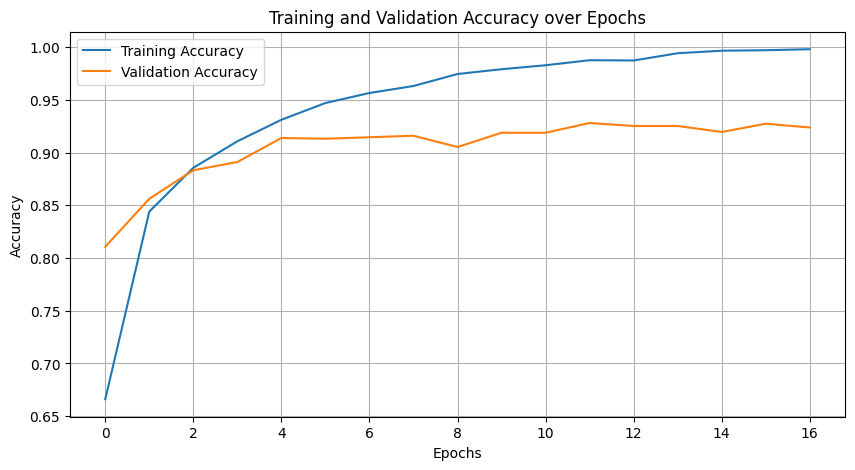

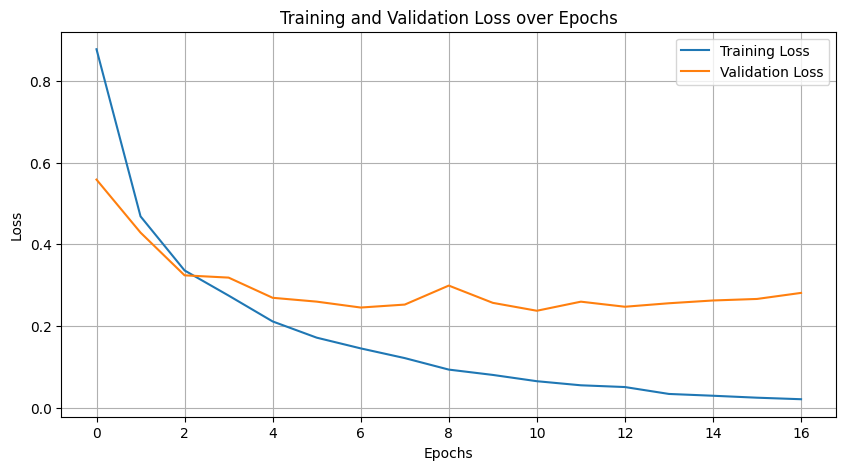

In [11]:
# Evaluate Model 1

model1.summary()

# print("Loss", model1_hist.history["loss"])
# print("Accuracy", model1_hist.history["accuracy"])
# print("Val_Loss", model1_hist.history["val_loss"])
# print("Val_Acc", model1_hist.history["val_accuracy"])

# test_loss, test_accuracy = model1.evaluate(X_test, y_test, verbose=2)
# print(f'Test Accuracy: {test_accuracy:.4f}')

y_pred_prob = model1.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

test_accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {test_accuracy:.4f}')

test_precision = precision_score(y_test, y_pred, average='weighted')
print(f'Test Precision: {test_precision:.4f}')

test_recall = recall_score(y_test, y_pred, average='weighted')
print(f'Test Recall: {test_recall:.4f}')

test_f1 = f1_score(y_test, y_pred, average='weighted')
print(f'Test F1: {test_f1:.4f}')

print(classification_report(y_test, y_pred))

train_loss = model1_hist.history['loss']
val_loss = model1_hist.history['val_loss']

train_accuracy = model1_hist.history['sparse_categorical_accuracy']
val_accuracy = model1_hist.history['val_sparse_categorical_accuracy']

# Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Plot training loss and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 128, 128, 50)      250       
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 64, 64, 50)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 64, 64, 50)        10050     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 32, 32, 50)        0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 51200)             0         
                                                                 
 dense_1 (Dense)             (None, 200)              

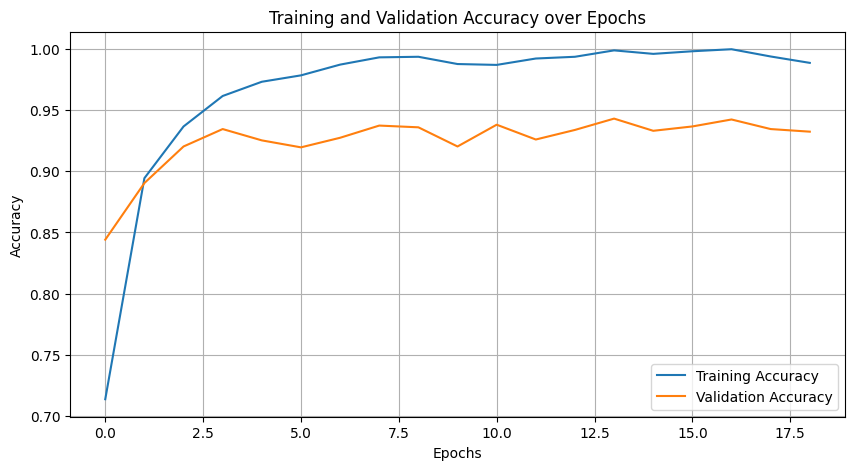

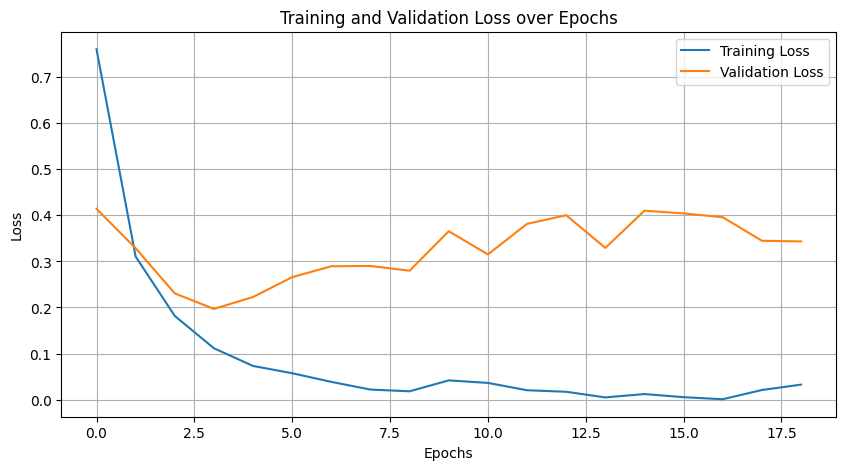

In [12]:
# Evaluate Model 2

model2.summary()

# print("Loss", model2_hist.history["loss"])
# print("Accuracy", model2_hist.history["accuracy"])
# print("Val_Loss", model2_hist.history["val_loss"])
# print("Val_Acc", model2_hist.history["val_accuracy"])

# test_loss, test_accuracy = model2.evaluate(X_test, y_test, verbose=2)
# print(f'Test Accuracy: {test_accuracy:.4f}')

y_pred_prob = model2.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

test_accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {test_accuracy:.4f}')

test_precision = precision_score(y_test, y_pred, average='weighted')
print(f'Test Precision: {test_precision:.4f}')

test_recall = recall_score(y_test, y_pred, average='weighted')
print(f'Test Recall: {test_recall:.4f}')

test_f1 = f1_score(y_test, y_pred, average='weighted')
print(f'Test F1: {test_f1:.4f}')

print(classification_report(y_test, y_pred))

train_loss = model2_hist.history['loss']
val_loss = model2_hist.history['val_loss']

train_accuracy = model2_hist.history['sparse_categorical_accuracy']
val_accuracy = model2_hist.history['val_sparse_categorical_accuracy']

# Plot the training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Plot training loss and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
def build_model(hp):
    model = Sequential()

    model.add(Conv2D(
        filters=hp.Choice('conv1_filters', [16, 32, 64]),
        kernel_size=hp.Choice('conv1_kernel', [3, 5]),
        activation='relu',
        padding='same',
        input_shape=(128, 128, 1)
    ))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(
        filters=hp.Choice('conv2_filters', [32, 64, 96]),
        kernel_size=hp.Choice('conv2_kernel', [3, 5]),
        activation='relu',
        padding='same'
    ))
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())

    model.add(Dense(
        units=hp.Choice('dense_units', [64, 128, 256]),
        activation='relu'
    ))
    model.add(Dropout(rate=hp.Choice('dropout_rate', [0.0, 0.2, 0.4])))

    model.add(Dense(4, activation='softmax'))

    optimizer_choice = hp.Choice('optimizer', ['adam', 'sgd'])
    learning_rate = hp.Choice('learning_rate', [1e-4, 1e-3, 1e-2])

    optimizer = Adam(learning_rate=learning_rate) if optimizer_choice == 'adam' else SGD(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['sparse_categorical_accuracy']
    )

    return model


In [16]:
automated_hyperparameter_tuning = True

if automated_hyperparameter_tuning:
    tuner = keras_tuner.RandomSearch(
        build_model,
        objective='val_sparse_categorical_accuracy',
        max_trials=8,
        executions_per_trial=1,
        directory=os.getcwd(),
        project_name='Hyperparameter_Tuning_Models_v2',
        overwrite=True
    )

    es_tuner = EarlyStopping(
        restore_best_weights=True,
        patience=4,
        monitor='val_sparse_categorical_accuracy',
        mode='max',
        verbose=2
    )

    tuner.search(
        x=X_train,
        y=y_train,
        epochs=12,
        validation_data=(X_val, y_val),
        callbacks=[es_tuner],
        verbose=2
    )

    tuner.results_summary()


Trial 8 Complete [00h 03m 33s]
val_sparse_categorical_accuracy: 0.4953736662864685

Best val_sparse_categorical_accuracy So Far: 0.927402138710022
Total elapsed time: 00h 50m 13s
Results summary
Results in /Users/vinsoncai/Documents/ACTL3143/Hyperparameter_Tuning_Models_v2
Showing 10 best trials
Objective(name="val_sparse_categorical_accuracy", direction="max")

Trial 0 summary
Hyperparameters:
conv1_filters: 64
conv1_kernel: 5
conv2_filters: 64
conv2_kernel: 3
dense_units: 256
dropout_rate: 0.4
optimizer: adam
learning_rate: 0.0001
Score: 0.927402138710022

Trial 2 summary
Hyperparameters:
conv1_filters: 16
conv1_kernel: 5
conv2_filters: 96
conv2_kernel: 3
dense_units: 128
dropout_rate: 0.2
optimizer: adam
learning_rate: 0.01
Score: 0.9217081665992737

Trial 5 summary
Hyperparameters:
conv1_filters: 16
conv1_kernel: 5
conv2_filters: 64
conv2_kernel: 3
dense_units: 256
dropout_rate: 0.0
optimizer: adam
learning_rate: 0.01
Score: 0.8797153234481812

Trial 4 summary
Hyperparameters:
conv

In [17]:
if automated_hyperparameter_tuning:
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    print('Best hyperparameters:', best_hps.values)
    best_model = tuner.hypermodel.build(best_hps)

    history = best_model.fit(
        X_train, y_train,
        epochs=25,
        validation_data=(X_val, y_val),
        callbacks=[es_tuner],
        verbose=2
    )


Best hyperparameters: {'conv1_filters': 64, 'conv1_kernel': 5, 'conv2_filters': 64, 'conv2_kernel': 3, 'dense_units': 256, 'dropout_rate': 0.4, 'optimizer': 'adam', 'learning_rate': 0.0001}
Epoch 1/25
132/132 - 33s - loss: 0.9332 - sparse_categorical_accuracy: 0.6259 - val_loss: 0.5166 - val_sparse_categorical_accuracy: 0.8448 - 33s/epoch - 250ms/step
Epoch 2/25
132/132 - 33s - loss: 0.4981 - sparse_categorical_accuracy: 0.8336 - val_loss: 0.3944 - val_sparse_categorical_accuracy: 0.8619 - 33s/epoch - 248ms/step
Epoch 3/25
132/132 - 35s - loss: 0.3768 - sparse_categorical_accuracy: 0.8747 - val_loss: 0.3171 - val_sparse_categorical_accuracy: 0.8861 - 35s/epoch - 268ms/step
Epoch 4/25
132/132 - 33s - loss: 0.3052 - sparse_categorical_accuracy: 0.9010 - val_loss: 0.2770 - val_sparse_categorical_accuracy: 0.8968 - 33s/epoch - 248ms/step
Epoch 5/25
132/132 - 31s - loss: 0.2554 - sparse_categorical_accuracy: 0.9086 - val_loss: 0.2730 - val_sparse_categorical_accuracy: 0.9011 - 31s/epoch - 2

In [18]:
if automated_hyperparameter_tuning:
    test_loss, test_accuracy = best_model.evaluate(X_test, y_test, verbose=2)
    print(f'Test Accuracy: {test_accuracy:.4f}')


44/44 - 3s - loss: 0.2550 - sparse_categorical_accuracy: 0.9409 - 3s/epoch - 68ms/step
Test Accuracy: 0.9409
